# Lab 3: Data Types and Arrays

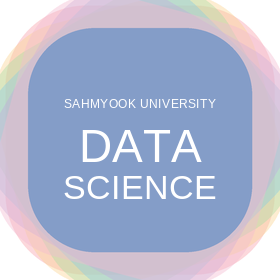

Welcome to Lab 3!

So far, we've used Python to manipulate numbers and work with tables. But we need to discuss data types to deepen our understanding of how to work with data in Python.

In this lab, you'll first see how to represent and manipulate another fundamental type of data: text.  A piece of text is called a *string* in Python. You'll also see how to work with *arrays* of data. An array could contain all the numbers between 0 and 100 or all the words in the chapter of a book. Lastly, you'll create tables and practice analyzing them with your knowledge of table operations. The [Python Reference](https://www.data8.org/sp26/reference/) has information that will be useful for this lab.

In [ ]:
# Setup (run this first!)
!pip install -q otter-grader datascience
!git clone https://github.com/jihyungkim94/datascience.git 2>/dev/null || true
import os, json
os.chdir('/content/datascience/lab/lab03')
os.makedirs('tests', exist_ok=True)
with open('lab03.ipynb') as _f:
    _nb = json.load(_f)
for _name, _test in _nb['metadata']['otter']['tests'].items():
    with open('tests/' + _name + '.py', 'w') as _f:
        _f.write('OK_FORMAT = True\n\ntest = ' + repr(_test) + '\n')
import otter
grader = otter.Notebook('lab03.ipynb')
print('Ready! (20 tests loaded)')

**Submission**: When you're finished, run every cell and check that the tests pass, then download the notebook with **File → Download → Download .ipynb** and upload it to the LMS.

Let's begin by setting up the tests and imports by running the cell below.

In [ ]:
# Just run this cell
import numpy as np
import math
from datascience import *

# No need to worry about what this code means
from IPython.display import Javascript, display
display(Javascript(r"""
(() => {
  function pathLooksLikeTyping(e) {
    const path = e.composedPath ? e.composedPath() : [];
    for (const n of path) {
      if (!n) continue;
      if (n.tagName === 'INPUT' || n.tagName === 'TEXTAREA') return true;
      if (n.isContentEditable) return true;
      const role = n.getAttribute?.('role');
      if (role === 'textbox' || role === 'combobox' || role === 'searchbox') return true;
      const ariaMulti = n.getAttribute?.('aria-multiline');
      if (ariaMulti === 'true') return true;
      const cls = (n.className || "").toString().toLowerCase();
    }
    return false;
  }
  function handler(e) {
    if (e.key !== 'o' && e.key !== 'O') return;
    if (pathLooksLikeTyping(e)) {
      e.stopPropagation();
      if (e.stopImmediatePropagation) e.stopImmediatePropagation();
      if (e.nativeEvent?.stopImmediatePropagation) e.nativeEvent.stopImmediatePropagation();
      return;
    }
    e.preventDefault();
    e.stopPropagation();
    if (e.stopImmediatePropagation) e.stopImmediatePropagation();
    if (e.nativeEvent?.stopImmediatePropagation) e.nativeEvent.stopImmediatePropagation();
  }
  window.addEventListener('keydown', handler, true);
  window.addEventListener('keypress', handler, true);
  console.log("Installed: 'o' won't toggle output; 'o' should type inside any textbox-like UI (including JupyTutor).");
})();
"""))

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 1. Text
Programming doesn't just concern numbers. Text is one of the most common data types used in programs. 

Text is represented by a **string value** in Python. The word "string" is a programming term for a sequence of characters. A string might contain a single character, a word, a sentence, or a whole book.

To distinguish text data from actual code, we demarcate strings by putting quotation marks around them. Single quotes (`'`) and double quotes (`"`) are both valid, but the types of opening and closing quotation marks must match. The contents can be any sequence of characters, including numbers and symbols. 

We've seen strings before in `print` statements.  Below, two different strings are passed as arguments to the `print` function. Notice that the `print` function automatically inserts a space between its two input string arguments (comma separated) in the output of this cell.

In [ ]:
print("I <3", 'Data Science')

Just as names can be given to numbers, names can be given to string values.  The names and strings aren't required to be similar in any way. Any name can be assigned to any string.

In [ ]:
one = 'two'
plus = '*'
print(one, plus, one)

---
**Question 1.1.** Yuri Gagarin was the first person to travel through outer space.  When he emerged from his capsule upon landing on Earth, he [reportedly](https://en.wikiquote.org/wiki/Yuri_Gagarin) had the following conversation with a woman and girl who saw the landing:

    The woman asked: "Can it be that you have come from outer space?"
    Gagarin replied: "As a matter of fact, I have!"

The cell below contains unfinished code.  Fill in the `...`s so that it prints out this conversation *exactly* as it appears above.

Hint: Examine how `woman_quote` is defined to include the double quotes.


In [ ]:
woman_asking = ...
woman_quote = '"Can it be that you have come from outer space?"'
gagarin_reply = 'Gagarin replied:'
gagarin_quote = ...

print(woman_asking, woman_quote)
print(gagarin_reply, gagarin_quote)

In [ ]:
grader.check("q11")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 1.1. String Methods

Strings can be transformed using **methods**. Recall that methods and functions are not the same thing. Here is the textbook section on string methods: [4.2.1 String Methods](https://inferentialthinking.com/chapters/04/2/1/String_Methods.html). 

Here's a sketch of how to call methods on a string:

    <expression that evaluates to a string>.<method name>(<argument>, <argument>, ...)
    
One example of a string method is `replace`, which replaces all instances of some part of the original string (or a *substring*) with a new string. 

    <original string>.replace(<old substring>, <new substring>)
    
`replace` returns (evaluates to) a new string, leaving the original string unchanged.
    
Try to predict the output of this example, then run the cell!

In [ ]:
# Replace one letter
bag = 'bag'
print(bag.replace('g', 't'), bag)

You can call functions on the results of other functions.  For example, `max(abs(-5), abs(3))` evaluates to 5.  Similarly, you can call methods on the results of other method or function calls.

You may have already noticed one difference between functions and methods - a function like `max` does not require a `.` before it's called, but a string method like `replace` does. The Python reference referred to in the opening paragraph might be useful in cases where you are unsure how to call a function or a method.

In [ ]:
# Calling replace on the output of another call to replace
'train'.replace('t', 'ing').replace('in', 'de')

Here's a picture of how Python evaluates a "chained" method call like that:

<img alt="Diagram of chained string methods: 'train'.replace('t','ing').replace('in','de') first becomes 'ingrain'.replace('in','de'), which then becomes 'degrade'." src="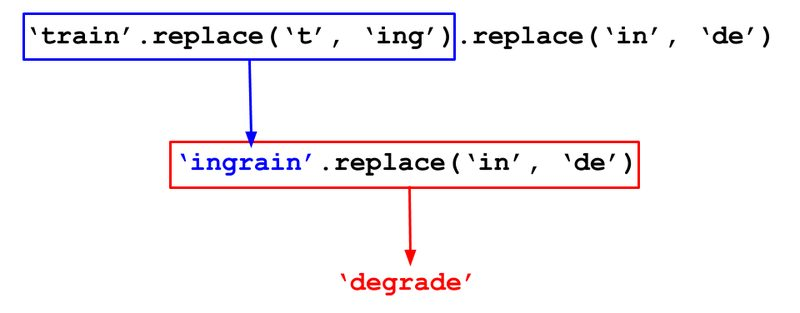"/>

---
**Question 1.1.1.** Use `replace` to transform the string `'hitchhiker'` into `'matchmaker'`. Assign your result to `new_word`.


In [ ]:
new_word = ...
new_word

In [ ]:
grader.check("q111")

There are many more string methods in Python, but most programmers don't memorize their names or how to use them.  In the "real world," people usually just search the internet for documentation and examples. A complete [list of string methods](https://docs.python.org/3/library/stdtypes.html#string-methods) appears in the Python language documentation. [Stack Overflow](http://stackoverflow.com) has a huge database of answered questions that often demonstrate how to use these methods to achieve various ends. Material covered in these resources that haven't already been introduced in this class will be out of scope. 

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 1.2. Converting to and from Strings

Strings and numbers are different *types* of values, even when a string contains the digits of a number. For example, evaluating the following cell causes an error because an integer cannot be added to a string.

_Note:_ An integer cannot be added to a string, and a float cannot be added to a string. However, we **can** add integers and floats!

In [ ]:
8 + "8"

However, there are built-in functions to convert numbers to strings and strings to numbers. Some of these built-in functions have restrictions on the type of argument they take:

|Function |Description|
|-|-|
|`int`|Converts a string of digits or a float to an integer ("int") value|
|`float`|Converts a string of digits (perhaps with a decimal point) or an int to a decimal ("float") value|
|`str`|Converts any value to a string|

Try to predict what data type and value `example` evaluates to, then run the cell.

In [ ]:
example = 8 + int("10") + float("8")

print(example)
print("This example returned a " + str(type(example)) + "!")

Suppose you're writing a program that looks for dates in a text, and you want your program to find the amount of time that elapsed between two years it has identified.  It doesn't make sense to subtract two texts, but you can first convert the text containing the years into numbers.

---

**Question 1.2.1.** Finish the code below to compute the number of years that elapsed between `one_year` and `another_year`.  Don't just write the numbers `1618` and `1648` (or `30`); use a conversion function to turn the given text data into numbers.


In [ ]:
# Some text data:
one_year = "1618"
another_year = "1648"

# Complete the next line.  Note that we can't just write:
#   another_year - one_year
# If you don't see why, try seeing what happens when you
# write that here.
difference = ...
difference

In [ ]:
grader.check("q121")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 1.3. Passing strings to functions

String values, like numbers, can be arguments to functions and can be returned by functions. 

The function `len` (derived from the word "length") takes a single string as its argument and returns the number of characters (including spaces and punctuation) in the string.

Note that it doesn't count *words*. `len("one small step for man")` evaluates to 22 characters, not 5 words.

**Question 1.3.1.**  Use `len` to find the number of characters in the long string in the next cell.  Characters include things like spaces and punctuation. Assign `sentence_length` to that number.

(The string is the first sentence of the English translation of the French [Declaration of the Rights of Man](http://avalon.law.yale.edu/18th_century/rightsof.asp).)  


In [ ]:
a_very_long_sentence = "The representatives of the French people, organized as a National Assembly, believing that the ignorance, neglect, or contempt of the rights of man are the sole cause of public calamities and of the corruption of governments, have determined to set forth in a solemn declaration the natural, unalienable, and sacred rights of man, in order that this declaration, being constantly before all the members of the Social body, shall remind them continually of their rights and duties; in order that the acts of the legislative power, as well as those of the executive power, may be compared at any moment with the objects and purposes of all political institutions and may thus be more respected, and, lastly, in order that the grievances of the citizens, based hereafter upon simple and incontestable principles, shall tend to the maintenance of the constitution and redound to the happiness of all."
sentence_length = ...
sentence_length

In [ ]:
grader.check("q131")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

## 2. Arrays

Computers are most useful when you can use a small amount of code to *do the same action* to *many different things*.

For example, in the time it takes you to calculate the 18% tip on a restaurant bill, a laptop can calculate 18% tips for every restaurant bill paid by every human on Earth that day.  (That's if you're pretty fast at doing arithmetic in your head!)

**Arrays** are how we put many values in one place so that we can operate on them as a group. For example, if `billions_of_numbers` is an array of numbers, the expression

    .18 * billions_of_numbers

gives a new array of numbers that contains the result of multiplying **each number** in `billions_of_numbers` by .18.  Arrays are not limited to numbers; we can also put all the words in a book into an array of strings.

Concretely, an array is a **collection of values of the same type**. 

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" /> 

### 2.1. Making arrays

First, let's learn how to manually input values into an array. This typically isn't how programs work. Normally, we create arrays by loading them from an external source, like a data file.

To create an array by hand, call the function `make_array`.  Each argument you pass to `make_array` will be in the array it returns.  Run this cell to see an example:

In [ ]:
make_array(0.125, 4.75, -1.3)

Each value in an array (in the above case, the numbers 0.125, 4.75, and -1.3) is called an *element* of that array.

Arrays themselves are also values, just like numbers and strings.  That means you can assign them to names or use them as arguments to functions. For example, `len(<some_array>)` returns the number of elements in `some_array`.

**Question 2.1.1.** Make an array containing the numbers 0, 1, -1, and $\pi$, in that order.  Name it `interesting_numbers`.  

*Hint:* How did you get the value $\pi$ in lab 2?  You can refer to it the same way here. The `math` module has been imported at the top of this notebook.


In [ ]:
interesting_numbers = ...
interesting_numbers

In [ ]:
grader.check("q211")

--- 
**Question 2.1.2.** Make an array containing the five strings `"Hello"`, `","`, `" "`, `"world"`, and `"!"`.  (The third one is a single space inside quotes.)  Name it `hello_world_components`.

*Note:* If you evaluate `hello_world_components`, you'll notice some extra information in addition to its contents: `dtype='<U5'`.  That's just NumPy's extremely cryptic way of saying that the data types in the array are strings.


In [ ]:
hello_world_components = ...
hello_world_components

In [ ]:
grader.check("q212")

#### `np.arange`
Arrays are provided by a package called [NumPy](http://www.numpy.org/) (pronounced "NUM-pie"). The package is called `numpy`, but it's standard to rename it `np` for brevity.  You can do that with:

    import numpy as np

Very often in data science, we want to work with many numbers that are evenly spaced within some range.  NumPy provides a special function for this called `arange`.  The line of code `np.arange(start, stop, step)` evaluates to an array with all the numbers starting at `start` and counting up by `step`, stopping **before** `stop` is reached.

Run the following cells to see some examples!

In [ ]:
# This array starts at 1 and counts up by 2
# and then stops before 6
np.arange(1, 6, 2)

In [ ]:
# This array doesn't contain 9
# because np.arange stops *before* the stop value is reached
np.arange(4, 9, 1)

In [ ]:
# The default start value of np.arange is 0
# The default step value of np.arange is 1
# This array defaults to start at 0 and count up by 1, but then stops before 5
# since np.arange was given one argument, start and step have the above defaults. 
np.arange(5)

---
**Question 2.1.3.** Import `numpy` as `np` and then use `np.arange` to create an array with the multiples of 99 from 0 up to (**and including**) 9999.  (So its elements are 0, 99, 198, 297, etc.)


In [ ]:
...
multiples_of_99 = ...
multiples_of_99

In [ ]:
grader.check("q213")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 2.2. Working with single elements of arrays ("indexing")
Let's work with a more interesting dataset.  The next cell creates an array called `population_amounts` that includes estimated world populations of every year from **1950** to roughly the present.  (The estimates come from the US Census Bureau website.)

Rather than type in the data manually, we've loaded them from a file on your computer called `world_population.csv`.  You'll learn how to do that later in this lab!

In [ ]:
population_amounts = Table.read_table("world_population.csv").column("Population")
population_amounts

Here's how we get the first element of `population_amounts`, which is the world population in the first year in the dataset, 1950.

In [ ]:
population_amounts.item(0)

The value of that expression is the number 2,557,628,654 (around 2.5 billion), because that's the first thing in the array `population_amounts`.

Notice that we wrote `.item(0)`, not `.item(1)`, to get the first element.  This is a weird convention in computer science.  **0 is called the *index* of the first item.**  It's the number of elements that appear *before* that item.  So 3 is the index of the 4th item.

Here are some more examples.  In the examples, we've given names to the things we get out of `population_amounts`.  Read and run each cell.

In [ ]:
# The population in 1962 is the 13th element in the array
# because it is 12 indices after 1950, which is at index 0. (1950 + 12 = 1962)

population_1962 = population_amounts.item(12)
population_1962

In [ ]:
# The 66th element is the population in 2015.
population_2015 = population_amounts.item(65)
population_2015

In [ ]:
# The array has only 66 elements, so this doesn't work.
# (There's no element with 66 other elements before it.)
population_2016 = population_amounts.item(66)
population_2016

Since `make_array` returns an array, we can call `.item(3)` on its output to get its 4th element, just like we "chained" together calls to the method `replace` earlier.

In [ ]:
make_array(-1, -3, 4, -2).item(3)

---
**Question 2.2.1.** Set `population_1973` to the world population in 1973, by getting the appropriate element from `population_amounts` using `item`.


In [ ]:
population_1973 = ...
population_1973

In [ ]:
grader.check("q221")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 2.3. Doing something to every element of an array
Arrays are primarily useful for doing the same operation many times, so we don't often have to use `.item` and work with single elements.

#### Rounding
Here is one simple question we might ask about world population:

> How big was the population in each year, rounded to the nearest million?

Rounding is often used with large numbers when we don't need as much precision in our numbers. One example of this is when we present data in tables and visualizations. 

We could try to answer our question using the `round` function that is built into Python and the `item` method you just saw. 

**Note:** the `round` function takes in two arguments: the number to be rounded, and the number of decimal places to round to. The second argument can be thought of as how many steps right or left you move from the decimal point. Negative numbers tell us to move left, and positive numbers tell us to move right. So, if we have `round(1234.5, -2)`, it means that we should move two places left, and then make all numbers to the right of this place zeroes. This would output the number 1200.0. On the other hand, if we have `round(6.789, 1)`, we should move one place right, and then make all numbers to the right of this place zeroes. This would output the number 6.8.

<img alt="Two examples of np.round: np.round(1234.5, -2) gives 1200.0 by moving two places left of the decimal, and np.round(6.789, 1) gives 6.8 by moving one place right of the decimal." src="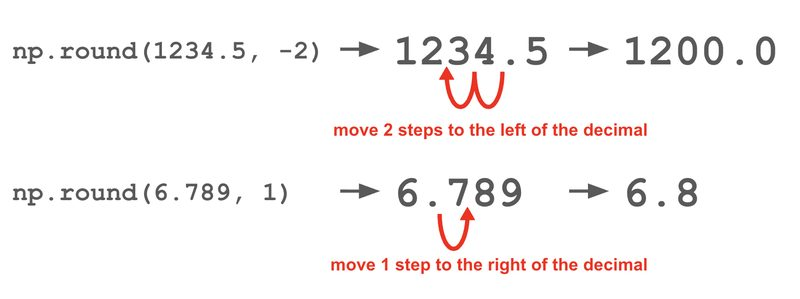">

In [ ]:
population_1950_magnitude = round(population_amounts.item(0), -6)
population_1951_magnitude = round(population_amounts.item(1), -6)
population_1952_magnitude = round(population_amounts.item(2), -6)
population_1953_magnitude = round(population_amounts.item(3), -6)
print(population_1950_magnitude, population_1951_magnitude, population_1952_magnitude, population_1953_magnitude)


But this is tedious and doesn't really take advantage of the fact that we are using a computer.

Instead, NumPy provides its own version of `round` that rounds each element of an array.  It takes in two arguments: a single array of numbers, and the number of decimal places to round to.  It returns an array of the same length, where the first element of the result is the first element of the argument rounded, and so on.

---

**Question 2.3.1.** Use `np.round` to compute the world population in every year, rounded to the nearest million (6 zeroes).  Give the result (an array of 66 numbers) the name `population_rounded`.  Your code should be very short.

In [ ]:
population_rounded = ...
population_rounded

In [ ]:
grader.check("q231")

What you just did is called **elementwise** application of `np.round`, since `np.round` operates separately on each element of the array that it's called on. Here's a picture of what's going on:

<img alt="Diagram of np.round applied elementwise to the array [11.111, 22.222, 88.888] with 1 decimal place, equal to np.round of each element, giving [11.1, 22.2, 88.9]." src="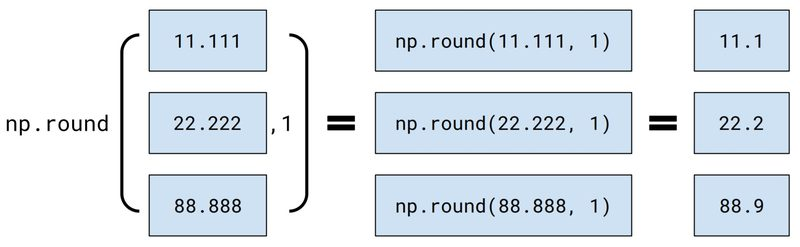">

The textbook's [section](https://www.inferentialthinking.com/chapters/05/1/Arrays)  on arrays has a useful list of NumPy functions that are designed to work elementwise, like `np.round`.

#### Arithmetic
Arithmetic also works elementwise on arrays, meaning that if you perform an arithmetic operation (like subtraction, division, etc) on an array, Python will do the operation to every element of the array individually and return an array of all of the results. For example, you can divide all the population numbers by 1 billion to get numbers in billions:

In [ ]:
population_in_billions = population_amounts / 1000000000
population_in_billions

You can do the same with addition, subtraction, multiplication, and exponentiation (`**`).



<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 3. Creating Tables

An array is useful for describing a single attribute of each element in a collection. For example, let's say our collection is all US States. Then an array could describe the land area of each state. 

Tables extend this idea by containing multiple columns stored and represented as arrays, each one describing a different attribute for every element of a collection. In this way, tables allow us to not only store data about many entities but to also contain several kinds of data about each entity. 

For example, in the cell below we have two arrays. The first one, `population_amounts`, was defined above in section 2.2 and contains the world population in each year (estimated by the US Census Bureau). The second array, `years`, contains the years themselves. These elements are in order, so the year and the world population for that year have the same index in their corresponding arrays.

In [ ]:
# Just run this cell

years = np.arange(1950, 2015+1)
print("Population column:", population_amounts)
print("Years column:", years)

Suppose we want to answer this question:

> In which year did the world's population cross 6 billion?

You could technically answer this question just from staring at the arrays, but it's a bit convoluted, since you would have to count the position where the population first crossed 6 billion, then find the corresponding element in the years array. In cases like these, it might be easier to put the data into a *`Table`*, a 2-dimensional type of dataset. 

The expression below:

- creates an empty table using the expression `Table()`,
- adds two columns by calling `with_columns` with four arguments (corresponding to the name of the column, the values for that column, the name of the second column, and the values for that column),
- assigns the result to the name `population`, and finally
- evaluates `population` so that we can see the table.

The strings `"Year"` and `"Population"` are column labels that we have chosen. The names `population_amounts` and `years` were assigned above to two arrays of the **same length**. The function `with_columns` (you can find the documentation [in the reference sheet](http://data8.org/sp26/reference)) takes in alternating strings (to represent column labels) and arrays (representing the data in those columns). The strings and arrays are separated by commas. 

_Note:_ When you want to add one column to a table, you can either use `with_columns` or `with_column` with two arguments (the column name and the array). However, if you want to add more than one column to a table, you must use `with_columns` with alternating arguments of strings and arrays.

In [ ]:
population = Table().with_columns(
    "Population", population_amounts,
    "Year", years
)
population

Now the data is combined into a single table! It's much easier to parse this data. If you need to know what the population was in 1959, for example, you can tell from a single glance.

---
**Question 3.1.** In the cell below, we've created 2 arrays. Using the steps above, assign `top_10_movies` to a table that has two columns called "Name" and "Rating", which hold `top_10_movie_names` and `top_10_movie_ratings` respectively.


In [ ]:
top_10_movie_names = make_array(
        'The Shawshank Redemption (1994)',
        'The Godfather (1972)',
        'The Godfather: Part II (1974)',
        'Pulp Fiction (1994)',
        "Schindler's List (1993)",
        'The Lord of the Rings: The Return of the King (2003)',
        '12 Angry Men (1957)',
        'The Dark Knight (2008)',
        'Il buono, il brutto, il cattivo (1966)',
        'The Lord of the Rings: The Fellowship of the Ring (2001)')
top_10_movie_ratings = make_array(9.2, 9.2, 9., 8.9, 8.9, 8.9, 8.9, 8.9, 8.9, 8.8)

top_10_movies = ...

# We've put this next line here 
# so your table will get printed out 
# when you run this cell.
top_10_movies

In [ ]:
grader.check("q31")

#### Loading a table from a file

In most cases, we aren't going to go through the trouble of typing in all the data manually. Instead, we load them in from an external source, like a data file. There are many formats for data files, but CSV ("comma-separated values") is the most common.

`Table.read_table(...)` takes one argument (a path to a data file in **string** format) and returns a table.  

**Question 3.2.** `imdb.csv` contains a table of information about the 250 highest-rated movies on IMDb.  Load it as a table called `imdb`.

(You may remember working with this table in Lab 2!)


In [ ]:
imdb = ...
imdb

In [ ]:
grader.check("q32")

Where did `imdb.csv` come from? Take a look at [this lab's folder](./). You should see a file called `imdb.csv`.

Open up the `imdb.csv` file in that folder and look at the format. What do you notice? The `.csv` filename ending says that this file is in the [CSV (comma-separated value) format](http://edoceo.com/utilitas/csv-file-format).

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 4. More Table Operations!

Now that you've worked with arrays, let's add a few more methods to the list of table operations that you saw in Lab 2.

#### `tbl.column`

`tbl.column` takes the column name of a table (in string format) as its argument and returns the values in that column as an **array**. 

In [ ]:
# Returns an array of movie names
top_10_movies.column('Name')

#### `take`
The table method `take` takes as its argument an array of numbers.  Each number should be the index of a row in the table.  It returns a **new table** with only those rows. 

You'll usually want to use `take` in conjunction with `np.arange` to take the first few rows of a table.

In [ ]:
# Take first 5 movies of top_10_movies
top_10_movies.take(np.arange(0, 5, 1))

The next three questions will give you practice with combining the operations you've learned in this lab and the previous one to answer questions about the `population` and `imdb` tables. First, check out the `population` table from section 2.

In [ ]:
# Run this cell to display the population table.
population

---
**Question 4.1.** Check out the `population` table from section 2 of this lab.  Compute the year when the world population first went above 6 billion. Assign the year to `year_population_crossed_6_billion`.

_Hint:_ How can we filter the table to only rows with population values over 6 billion? How can we find the first year of this filtered table? Review some of the table methods in the [Python Reference Sheet](https://www.data8.org/sp26/reference/)!


In [ ]:
year_population_crossed_6_billion = ...
year_population_crossed_6_billion

In [ ]:
grader.check("q41")

---
**Question 4.2.** Find the average rating for movies released before the year 2000 and the average rating for movies released in the year 2000 or after for the movies in `imdb`.

*Hint*: Think of the steps you need to do (take the average, find the ratings, find movies released in 20th/21st centuries), and try to put them in an order that makes sense.


In [ ]:
before_2000 = ...
after_or_in_2000 = ...
before_2000_avg = ...
after_or_in_2000_avg = ...
print("Average before 2000 rating:", before_2000_avg)
print("Average after or in 2000 rating:", after_or_in_2000_avg)

In [ ]:
grader.check("q42")

---
**Question 4.3.** Here's a challenge: Find the number of movies that came out in *even* years.

*Hint:* The operator `%` computes the remainder when dividing by a number.  So `5 % 2` is 1 and `6 % 2` is 0.  A number is even if the remainder is 0 when you divide by 2.

*Hint 2:* `%` can be used on arrays, operating elementwise like `+` or `*`.  So `make_array(5, 6, 7) % 2` is `array([1, 0, 1])`.

*Hint 3:* Add a new column called "Year Remainder" that's the remainder when each movie's release year is divided by 2. To do this, you can use `tbl.with_column(col_name, col_values)`: a table method that takes in the name of the new column and an array of values and returns a copy of the original `tbl` with the new column.  Then, use `where` to find rows where that new column is equal to 0.  Finally, use `num_rows` to count the number of such rows.

*Note:* These steps can be chained in one single statement, or broken up across several lines with intermediate names assigned. You’re always welcome to break down problems however you wish!


In [ ]:
num_even_year_movies = ...
num_even_year_movies

In [ ]:
grader.check("q43")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 5. More Array Practice

The following questions will be great practice for learning how to generate arrays in different ways, as well as executing different methods of array arithmetic!


#### 5.1 `np.arange` (cont.)

##### Temperature readings
NOAA (the US National Oceanic and Atmospheric Administration) operates weather stations that measure surface temperatures at different sites around the United States.  The hourly readings are [publicly available](http://www.ncdc.noaa.gov/qclcd/QCLCD?prior=N) if you are curious.

Suppose we download all the hourly data from the Oakland, California site for the month of December 2015.  To analyze the data, we want to know when each reading was taken, but we find that the data don't include the timestamps of the readings (the time at which each one was taken).

However, we know the first reading was taken at the first instant of December 2015 (midnight on December 1st) and each subsequent reading was taken exactly 1 hour after the last.

--- 
**Question 5.1.1.** Create an array of the *time, in seconds, since the start of the month* at which **each hourly reading** was taken.  Name it `collection_times`.

*Hint 1:* There were 31 days in December, which is equivalent to ($31 \times 24$) hours or ($31 \times 24 \times 60 \times 60$) seconds.  So your array should have $31 \times 24$ elements in it.

*Hint 2:* The `len` function works on arrays, too!  If your `collection_times` isn't passing the tests, check its length and make sure it has $31 \times 24$ elements.


In [ ]:
collection_times = ...
collection_times

In [ ]:
grader.check("q511")

#### 5.2 Doing something to every element of an array (cont.)

Calculate a tip on several restaurant bills at once (in this case just 3):

In [ ]:
restaurant_bills = make_array(20.12, 39.90, 31.01)
print("Restaurant bills:\t", restaurant_bills)

# Array multiplication
tips = .2 * restaurant_bills
print("Tips:\t\t\t", tips)

<img alt="Diagram of scalar multiplication: 0.2 times the array [20.12, 39.90, 31.01] equals the elementwise products [0.2*20.12, 0.2*39.90, 0.2*31.01]." src="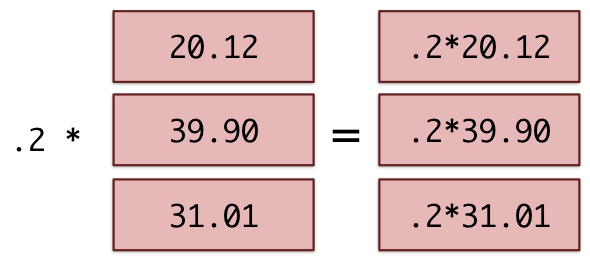">

---

**Question 5.2.1** Suppose the total charge at a restaurant is the original bill plus the tip. If the tip is 20%, that means we can multiply the original bill by 1.2 to get the total charge.  Compute the total charge for each bill in `restaurant_bills`, and assign the resulting array to `total_charges`.


In [ ]:
total_charges = ...
total_charges

In [ ]:
grader.check("q521")

---

**Question 5.2.2.** The array `more_restaurant_bills` contains 100,000 bills!  Compute the total charge for each one in `more_restaurant_bills`.  How is your code different?


In [ ]:
more_restaurant_bills = Table.read_table("more_restaurant_bills.csv").column("Bill")
more_total_charges = ...
more_total_charges

In [ ]:
grader.check("q522")

The function `sum` takes a single array of numbers as its argument.  It returns the sum of all the numbers in that array (so it returns a single number, not an array).

---

**Question 5.2.3.** What was the sum of all the bills in `more_restaurant_bills`, *including tips*?


In [ ]:
sum_of_bills = ...
sum_of_bills

In [ ]:
grader.check("q523")

---

**Question 5.2.4.** The powers of 2 ($2^0 = 1$, $2^1 = 2$, $2^2 = 4$, etc) arise frequently in computer science.  (For example, you may have noticed that storage on smartphones or USBs come in powers of 2, like 16 GB, 32 GB, or 64 GB.)  Use `np.arange` and the exponentiation operator `**` to compute the first 30 powers of 2, starting from `2^0`.

*Hint 1:* `np.arange(1, 2**30, 1)` creates an array with $2^{30}$ elements and **will crash your kernel**.

*Hint 2:* Part of your solution will involve `np.arange`, but your array shouldn't have more than 30 elements.


In [ ]:
powers_of_2 = ...
powers_of_2

In [ ]:
grader.check("q524")

<hr style="border: 5px solid #4a6591;" />
<hr style="border: 1px solid #7a98c7;" />

### 6. Jupytutor Survey

We hope your experience using Jupytutor has been smooth and helpful for you!

Please fill out the survey below and input the secret phrase that is shown at the end of the form when you submit. Please assign this phrase to `secret` as a string in the cell below!

Find the survey [in the course survey form](https://docs.google.com/forms/d/e/1FAIpQLSfzCSqSbmq2plpyAQKWa8IbK1GlZvIeIZdxH43F-yeaftz8sQ/viewform?usp=publish-editor).

In [ ]:
secret = ...

In [ ]:
grader.check("q6")

### Pets of this data science course

Jinxy is so proud of you for finishing.

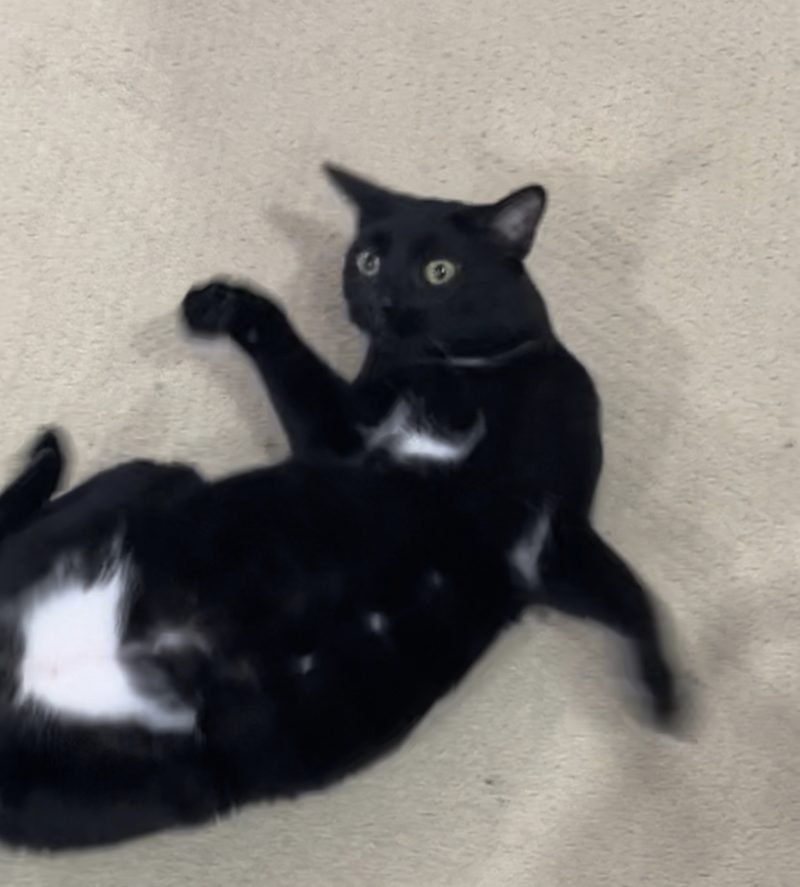

Congrats on completing Lab 3!


---

You're done with lab!

**Important submission steps:**
1. Run all the cells and verify that every test passes.
2. Choose **File → Download → Download .ipynb**.
3. Upload the `.ipynb` file to the LMS.

**Make sure every cell has been run before you download — the outputs are part of what you hand in.**


---

To double-check your work, the cell below will rerun all of the autograder tests.

In [ ]:
grader.check_all()

### Submission
1. Run `grader.check_all()` above and make sure all tests pass.
2. **File → Download → Download .ipynb**
3. Upload the `.ipynb` file to the LMS.

_(`grader.export()` does not work on Google Colab, so it has been removed.)_